<a href="https://colab.research.google.com/github/TomaszWlo/learning-git-task/blob/master/zadanie_8_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("fatal-police-shootings-data.csv")

table = df.groupby(["race", "signs_of_mental_illness"]).size().unstack(fill_value=0)
table["%"] = table.apply(lambda row: row[True] / (row[True] + row[False]) * 100,axis=1).round()


print(table)


signs_of_mental_illness  False  True     %
race                                      
A                           69    24  26.0
B                         1114   184  14.0
H                          745   157  17.0
N                           64    14  18.0
O                           37    11  23.0
W                         1763   713  29.0


Rasa "W" charakteryzuje sie najwiekszym odsetkiem znamion choroby psychicznej.

/tmp/ipykernel_1245/2915609214.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table_days = df.groupby("weekday").size().reset_index(name="incident count")


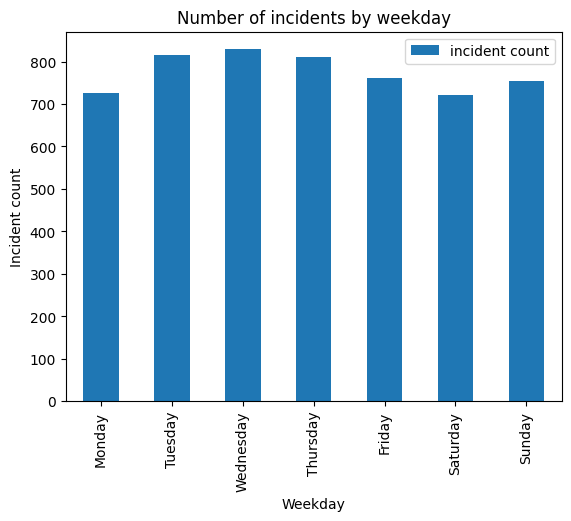

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("fatal-police-shootings-data.csv")

df["date"] = pd.to_datetime(df["date"])
df["weekday"] = df["date"].dt.day_name()

days_order = ["Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"]

df["weekday"] = pd.Categorical(df["weekday"], categories=days_order, ordered=True)

table_days = df.groupby("weekday").size().reset_index(name="incident count")

table_days.plot(kind="bar", x="weekday", y="incident count")

plt.title("Number of incidents by weekday")
plt.xlabel("Weekday")
plt.ylabel("Incident count")

plt.show()

In [4]:
import requests
import pandas as pd

df = pd.read_csv("fatal-police-shootings-data.csv")

'''
url_state_codes = ("https://en.wikipedia.org/wiki/List_of_U.S._state_and_territory_abbreviations")
url_population = ("https://simple.wikipedia.org/wiki/List_of_U.S._states_by_population")

headers = {"User-Agent": "Mozilla/5.0"}

html_state_codes = requests.get(url_state_codes, headers=headers).text
html_population = requests.get(url_population, headers=headers).text

state_codes = pd.read_html(html_state_codes)[1]
population = pd.read_html(html_population)[0]

state_codes_table = state_codes.to_csv('state codes', index=False)
population_table = population.to_csv('population', index=False)
'''

sctble = pd.read_csv('state codes')  # sct - skrot od state_codes_table
ptble = pd.read_csv('population')  # sct - skrot od population_table

incidents = df.groupby("state")['state'].value_counts()

states_codes_n_population = pd.merge(sctble, ptble,on='name', how='inner')
final_table = pd.merge(states_codes_n_population, incidents, on='state', how='inner')


final_table["odsetek"] = (final_table["count"] / final_table["Census population"]) * 1000

final_table[['state', "Census population", 'odsetek']].sort_values(by='odsetek' , ascending=False).head(10)


,state,Census population,odsetek
1,AK,733391,0.053178
24,NM,2117522,0.050059
29,OK,3959353,0.041421
2,AZ,7151502,0.035517
21,NV,3104614,0.030922
40,WV,1793716,0.030105
20,MT,1084225,0.028592
3,AR,3011524,0.027561
18,MI,2961279,0.026340
41,WY,576851,0.024270


Stanem o najwyższym wskaźnikiem incydentów na 1000 mieszkańców jest Alaska(AK)